In [19]:
import decoupler as dc
from scipy.stats import rankdata
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
from scipy.sparse import csr_matrix, issparse
from scipy import sparse
from tqdm.auto import tqdm
from scipy.special import ndtr
import re
import gc
import matplotlib.pyplot as plt
import warnings

import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

warnings.filterwarnings("ignore")

In [2]:
from src.preprocessing import read_adata_file
from src.preprocessing import preprocess_adata
from src.preprocessing import read_prior_network_file
from src.preprocessing import read_prior_network_file
from src.preprocessing import get_single_perturbation

### Import and read necessary files and data

In [ ]:
# Let's first download the datasets from https://zenodo.org/record/7041849
datasets = [
    "FrangiehIzar2021_RNA",
    "GasperiniShendure2019_lowMOI",
    "NormanWeissman2019_filtered",
    "PapalexiSatija2021_eccite_RNA",
    "ReplogleWeissman2022_K562_essential",
    "ReplogleWeissman2022_rpe1",
    "TianKampmann2021_CRISPRa",
    "TianKampmann2021_CRISPRi",
]

dataset_directory = "scPerturbDatasets"
os.makedirs(dataset_directory, exist_ok=True)

for dataset in datasets:
    if not os.path.exists(f"{dataset_directory}/{dataset}.h5ad"):
        !wget "https://zenodo.org/records/7041849/files/{dataset}.h5ad?download=1" -O {dataset_directory}/{dataset}.h5ad

--2026-01-28 10:51:39--  https://zenodo.org/records/7041849/files/GasperiniShendure2019_lowMOI.h5ad?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.52.235, 188.185.43.153
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322716827 (308M) [application/octet-stream]
Saving to: ‘scPerturbDatasets/GasperiniShendure2019_lowMOI.h5ad’

scPerturbDatasets/G 100%[===================>] 307.77M   573KB/s    in 11m 28s 

2026-01-28 11:03:08 (458 KB/s) - ‘scPerturbDatasets/GasperiniShendure2019_lowMOI.h5ad’ saved [322716827/322716827]



In [ ]:
# Also lets download the generated activity scores for each datasets and for each methods from google drive.
!uv pip install gdown

import os
import gdown

file_id = '1POdLzQxnjbXw6lGuIn89CsnM1x0S5lvB'
url = f'https://drive.google.com/uc?id={file_id}'
zip_filename = 'generated_scores.zip'
target_folder = 'generated_scores'

os.makedirs(target_folder, exist_ok=True)

print("Downloading...")
gdown.download(url, zip_filename, quiet=False, fuzzy=True)

print("Unzipping...")
!unzip -o -q {zip_filename} -d {target_folder}

if os.path.exists(zip_filename):
    os.remove(zip_filename)

print(f"Success! Activity scores are in: {target_folder}/")

For example: lets run z-aggregate on the PapalexiSatija2021_eccite_RNA dataset from scPerturbDatasets.

In [ ]:
dataset_name = f"{dataset_directory}/PapalexiSatija2021_eccite_RNA.h5ad"
prior_file = "../../data/causal-priors.tsv"
min_targets = 5

adata = read_adata_file(dataset_name)

adata = preprocess_adata(adata)  # Uses default parameters. To see default parameters refer to README.md

prior_network = read_prior_network_file(prior_file)
# Filter targets
valid_targets = set(adata.var_names)
net_filtered = prior_network[prior_network["target"].isin(valid_targets)].copy()

# Filter sources
source_counts = net_filtered["source"].value_counts()
valid_sources = source_counts[source_counts >= min_targets].index
net_filtered = net_filtered[net_filtered["source"].isin(valid_sources)].reset_index(drop=True)

common_tfs = net_filtered["source"].unique().tolist()

2026-01-23 16:02:32 | [INFO] Reading expression data from: scPerturbDatasets/PapalexiSatija2021_eccite_RNA.h5ad
2026-01-23 16:02:34 | [INFO]    Loaded data shape: 20729 cells x 18649 genes
2026-01-23 16:02:34 | [INFO] Starting Preprocessing...
2026-01-23 16:02:34 | [INFO]    Filtered cells (min_genes=1000): Removed 0 cells.
2026-01-23 16:02:35 | [INFO]    Filtered genes (min_cells=10): Removed 915 genes.
2026-01-23 16:02:35 | [INFO]    Mitochondrial filter (<20.0%): Removed 0 cells.
2026-01-23 16:02:36 | [INFO] Preprocessing complete. Final shape: 20729 cells x 17734 genes
2026-01-23 16:02:36 | [INFO] Loading prior network from: ../../data/causal-priors.tsv
2026-01-23 16:02:36 | [INFO]    Loaded 12071 interactions. Unique TFs: 1918


In [ ]:
if "perturbation" in adata.obs.columns:
    adata.obs["condition_clean"] = adata.obs["perturbation"].apply(get_single_perturbation)
else:
    raise ValueError("perturbation is not available")


perturbed_tfs = adata.obs["condition_clean"].unique().tolist()
perturbed_tfs

['STAT2',
 'CAV1',
 'STAT1',
 'CD86',
 'IRF7',
 'control',
 'ATF2',
 'STAT3',
 'JAK2',
 'NFKBIA',
 'SMAD4',
 'STAT5A',
 'CMTM6',
 'IFNGR1',
 'UBE2L6',
 'PDCD1LG2',
 'CUL3',
 'BRD4',
 'MARCH8',
 'IRF1',
 'POU2F2',
 'ETV7',
 'IFNGR2',
 'TNFRSF14',
 'SPI1',
 'MYC']

In [14]:
# Common perturbed tfs which is common to common transcription factors and also perturbed TFs
common_perturbed_tfs = sorted(
    list(set(common_tfs) & set(adata.obs["condition_clean"].unique()))
)
common_perturbed_tfs

['ATF2',
 'IRF1',
 'JAK2',
 'MYC',
 'NFKBIA',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT3',
 'STAT5A']

### Run z-aggregate
To learn more about how to run z-aggregate refer to [README.md](../../README.md).

In [ ]:
!uv run z-aggregate \
    --dataset {dataset_directory}/PapalexiSatija2021_eccite_RNA.h5ad \
    --priors ../../data/causal-priors.tsv \
    --output results \
    --verbose \
    --min-targets 5 \
    --weight-type Uniform \
    --preprocess

2026-01-23 16:03:08 - INFO - Reading expression data from: scPerturbDatasets/PapalexiSatija2021_eccite_RNA.h5ad
2026-01-23 16:03:09 - INFO -    Loaded data shape: 20729 cells x 18649 genes
2026-01-23 16:03:09 - INFO - Starting Preprocessing...
2026-01-23 16:03:10 - INFO -    Filtered cells (min_genes=1000): Removed 0 cells.
2026-01-23 16:03:10 - INFO -    Filtered genes (min_cells=10): Removed 915 genes.
2026-01-23 16:03:11 - INFO -    Mitochondrial filter (<20.0%): Removed 0 cells.
2026-01-23 16:03:12 - INFO - Preprocessing complete. Final shape: 20729 cells x 17734 genes
2026-01-23 16:03:12 - INFO - Loading prior network from: ../../data/causal-priors.tsv
2026-01-23 16:03:12 - INFO -    Loaded 12071 interactions. Unique TFs: 1918
2026-01-23 16:03:12 - INFO - Computing weights using strategy: Uniform
2026-01-23 16:03:12 - INFO -    Network Overlap: 9414/12071 edges (77.99%) target genes present in dataset.
2026-01-23 16:03:12 - INFO -    Weights computed successfully.
2026-01-23 16:03

In [17]:
z_aggregate_scores = pd.read_csv("results/PapalexiSatija2021_eccite_RNA_z_aggregate_scores.tsv", sep="\t")
z_aggregate_scores = z_aggregate_scores[common_perturbed_tfs]
z_aggregate_scores

,ATF2,IRF1,JAK2,MYC,NFKBIA,SMAD4,SPI1,STAT1,STAT3,STAT5A
0,-1.174030,-3.049558,-0.467471,3.496645,-2.419131,-0.622591,-0.930053,-1.972314,-2.848724,-2.806877
1,-0.671710,-0.288236,-0.306212,1.184745,-1.404851,-1.987099,4.628192,-1.896691,0.762200,1.223099
2,0.605762,-5.344849,0.457201,4.944212,7.386531,0.081829,1.951405,0.045059,2.527942,2.159402
3,0.316670,-2.228214,26.050256,1.744918,-2.518665,-0.529739,0.020271,0.356888,7.484369,-0.283003
4,1.637622,0.558385,3.521391,0.028123,1.159416,-0.225948,2.326073,1.522197,0.308092,0.161738
...,...,...,...,...,...,...,...,...,...,...
20724,0.000286,1.088357,-0.802162,2.460993,0.264227,0.059026,0.051582,2.289567,3.106820,1.017236
20725,-1.133515,1.395672,0.968980,-3.099152,0.233623,0.217533,2.069333,1.099555,0.530600,0.760751
20726,0.777186,0.868480,-0.777281,0.574165,-0.390046,-0.179318,0.510325,-0.484978,0.576134,-0.726617
20727,0.083734,-0.615894,-1.021148,-1.643588,-0.965722,1.238207,-0.487351,0.039671,-0.483735,-1.061645


### Run ulm

In [ ]:
dc.mt.ulm(adata, net_filtered, tmin=min_targets)

ulm_scores = adata.obsm["score_ulm"]
ulm_scores = ulm_scores[common_perturbed_tfs]
ulm_scores

,ATF2,IRF1,JAK2,MYC,NFKBIA,SMAD4,SPI1,STAT1,STAT3,STAT5A
AAACCTGAGCCAGAAC,-0.799548,3.007268,-0.668139,10.520226,0.159411,0.904651,3.039752,2.415834,3.618687,0.912844
AAACCTGAGTGGACGT,0.123917,5.775766,0.895832,9.080714,1.247037,0.421926,5.637151,3.299509,7.705496,5.320741
AAACCTGCATGAGCGA,0.555431,1.249729,1.272834,10.494698,5.943986,1.632218,4.207085,3.578693,6.344167,3.362913
AAACCTGTCTTGTCAT,1.521060,4.615201,3.148195,11.016030,0.675637,1.975630,4.356332,5.640392,8.286559,2.921933
AAACGGGAGAACAACT,1.956848,8.334405,3.167084,8.996078,4.303509,1.552955,6.102441,7.898764,8.520391,5.791075
...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,-0.321925,6.565752,-0.187132,9.825651,2.608102,1.464235,3.587454,6.231366,6.218972,3.975187
TTTGTCAGTGACGGTA,-0.192138,8.353528,2.948498,7.449128,3.540180,2.006820,6.534667,6.630486,7.037724,3.635993
TTTGTCAGTTCCACAA,0.043888,7.116414,0.224634,8.566553,1.912875,0.045803,4.291735,4.004580,6.015348,2.654836
TTTGTCATCACGCATA,0.486455,5.198832,-0.221909,7.706558,1.551899,2.788543,3.587070,4.812230,5.420733,2.793410


### Run viper

In [ ]:
sc.pp.scale(adata)
dc.mt.viper(adata, net_filtered, tmin=min_targets)

viper_scores = adata.obsm["score_viper"]
viper_scores[common_perturbed_tfs]
viper_scores

### Benchmark

#### Figure 2. ROC Curve

ROC curves of three methods (z-aggregate, ulm, viper) used in the paper can be generated using the code below.
1. IRF1 from NormanWeissman2019_filtered
2. SRF from ReplogleWeissman2022_rpe1
3. STAT1 from PapalexiSatija2021_eccite_RNA

In [ ]:
dataset_metadata = {
    "FrangiehIzar2021_RNA": {
        "is_activation": False,
    },
    "ReplogleWeissman2022_rpe1": {
        "is_activation": False,
    },
    "ReplogleWeissman2022_K562_essential": {
        "is_activation": False,
    },
    "NormanWeissman2019_filtered": {
        "is_activation": True,
    },
    "GasperiniShendure2019_lowMOI": {
        "is_activation": False,
    },
    "PapalexiSatija2021_eccite_RNA": {
        "is_activation": False,
    },
    "TianKampmann2021_CRISPRa": {
        "is_activation": True,
    },
    "TianKampmann2021_CRISPRi": {
        "is_activation": False,
    },
}

2026-01-24 15:40:54 | [INFO] Reading expression data from: scPerturbDatasets/PapalexiSatija2021_eccite_RNA.h5ad



Processing Dataset: PapalexiSatija2021_eccite_RNA
Target TFs: ['STAT1']


2026-01-24 15:40:56 | [INFO]    Loaded data shape: 20729 cells x 18649 genes
2026-01-24 15:40:56 | [INFO] Starting Preprocessing...
2026-01-24 15:40:56 | [INFO]    Filtered cells (min_genes=1000): Removed 0 cells.
2026-01-24 15:40:57 | [INFO]    Filtered genes (min_cells=10): Removed 915 genes.
2026-01-24 15:40:57 | [INFO]    Mitochondrial filter (<20.0%): Removed 0 cells.
2026-01-24 15:40:58 | [INFO] Preprocessing complete. Final shape: 20729 cells x 17734 genes


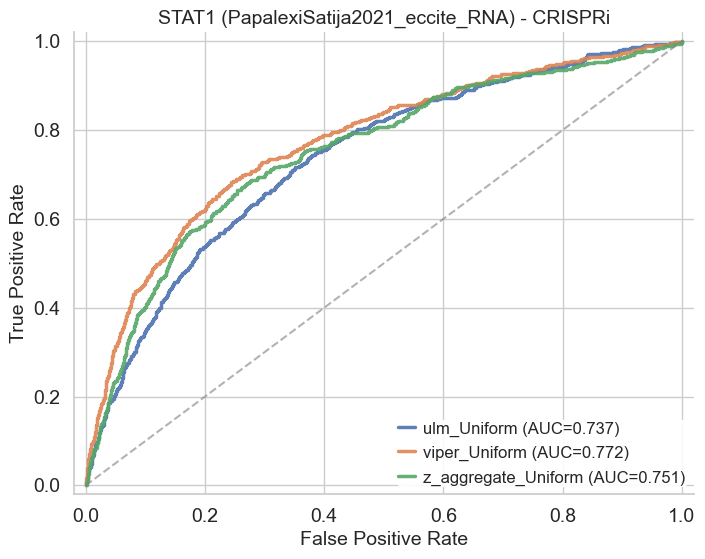

In [ ]:
def set_publication_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams.update(
        {
            "font.size": 14,
            "axes.labelsize": 14,
            "axes.titlesize": 14,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "legend.fontsize": 12,
            "legend.title_fontsize": 14,
            "figure.figsize": (8, 6),
            "figure.dpi": 100,
            "lines.linewidth": 2.5,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none"
        }
    )
    

def plot_roc_for_targets(targets_dict, dataset_meta):
    method_colors = {
        "z-aggregate": "#81c784ff",
        "ulm": "#64b5f6ff",
        "viper": "#ea907aff",
    }

    output_base_dir = "generated_scores"
    os.makedirs(output_base_dir, exist_ok=True)

    for dataset_name, tfs_to_plot in targets_dict.items():
        if dataset_name not in dataset_meta:
            print(f"Skipping {dataset_name}: Metadata not found.")
            continue

        print(f"\n{'=' * 80}")
        print(f"Processing Dataset: {dataset_name}")
        print(f"Target TFs: {tfs_to_plot}")
        print(f"{'=' * 80}")

        params = dataset_meta[dataset_name]
        is_activation = params["is_activation"]

        # 1. Load Ground Truth
        adata_path = f"scPerturbDatasets/{dataset_name}.h5ad"
        if not os.path.exists(adata_path):
            print(f"File not found: {adata_path}")
            continue

        adata = read_adata_file(adata_path)
        adata = preprocess_adata(adata)

        if "perturbation" in adata.obs.columns:
            adata.obs["condition_clean"] = adata.obs["perturbation"].apply(get_single_perturbation)
        else:
            adata.obs["condition_clean"] = adata.obs.index

        binary_matrix_full = pd.get_dummies(adata.obs["condition_clean"])
        available_tfs = [tf for tf in tfs_to_plot if tf in binary_matrix_full.columns]

        if not available_tfs:
            print("None of the requested TFs found in dataset.")

        binary_matrix = binary_matrix_full[available_tfs].copy()
        binary_matrix.index = binary_matrix.index.astype(str)

        # 2. Load Scores
        score_dir = f"generated_scores/{dataset_name}/"
        method_dfs = {}

        if os.path.exists(score_dir):
            for file_name in os.listdir(score_dir):
                if file_name.endswith(".feather") and "_Uniform_" in file_name:
                    method_key = (
                        file_name.replace(f"_{dataset_name}", "").replace(".feather", "").replace("_Uniform_", "")
                    )
                    try:
                        path = os.path.join(score_dir, file_name)
                        df = pd.read_feather(path)
                        if isinstance(df.index, pd.RangeIndex):
                            df = df.set_index(df.columns[0])
                        df.index = df.index.astype(str)
                        method_dfs[method_key] = df
                    
                    except Exception as e:
                        print(f"Error loading {file_name}: {e}")

        if not method_dfs:
            continue

        # 3. Plotting Loop
        for tf in available_tfs:
            fig, ax = plt.subplots(figsize=(8, 6))

            y_true_raw = binary_matrix[tf]
            plotted_any = False

            for method_name in sorted(method_dfs.keys()):
                score_df = method_dfs[method_name]

                common_cells = y_true_raw.index.intersection(score_df.index)
                if len(common_cells) == 0 or tf not in score_df.columns:
                    continue

                y_true = y_true_raw.loc[common_cells].values
                y_pred = score_df.loc[common_cells, tf].values

                if y_true.sum() < 1:
                    continue

                if not is_activation:
                    y_pred = -y_pred

                fpr, tpr, _ = roc_curve(y_true, y_pred)
                roc_auc = auc(fpr, tpr)

                color = "#52DCE9"  # Default gray
                for key, col in method_colors.items():
                    if key.lower() in method_name.lower():
                        color = col
                        break
                ax.plot(fpr, tpr, label=f"{method_name} (AUC={roc_auc:.3f})", alpha=0.9)
                plotted_any = True

            if plotted_any:
                ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", alpha=0.6)
                ax.set_xlim([-0.02, 1.02])
                ax.set_ylim([-0.02, 1.02])
                ax.set_xlabel("False Positive Rate")
                ax.set_ylabel("True Positive Rate")
                sns.despine(ax=ax)
                mode_str = "CRISPRa" if is_activation else "CRISPRi"
                ax.set_title(f"{tf} ({dataset_name}) - {mode_str}")
                ax.legend(loc="lower right", frameon=True, framealpha=0.9, edgecolor="white")

                # Save as SVG
                # out_name = f"ROC_{dataset_name}_{tf}.svg"
                # out_path = os.path.join(output_base_dir, out_name)
                # plt.savefig(out_path, format="svg", dpi=300, bbox_inches="tight")
                plt.show()
                plt.close()
            else:
                plt.close()
                print(f"     [Skipped] {tf}")

set_publication_style()

targets_to_plot = {
    "ReplogleWeissman2022_rpe1": ["SRF"],
    "NormanWeissman2019_filtered": ["IRF1"],
    "PapalexiSatija2021_eccite_RNA": ["STAT1"]
}

try:
    plot_roc_for_targets(targets_to_plot, dataset_metadata)
except Exception as e:
    print("CRITICAL ERROR:", e)

#### Figure 3. ROC curves of different weight types in z-aggregate

1. IRF1 from NormanWeissman2019_filtered
2. STAT1 from PapalexiSatija2021_eccite_RNA
3. GATA1 from ReplogleWeissman2022_K562_essential
4. MAX from ReplogleWeissman2022_K562_essential
5. ELL from ReplogleWeissman2022_rpe1
6. SRF from ReplogleWeissman2022_rpe1

2026-01-24 15:41:14 | [INFO] Reading expression data from: scPerturbDatasets/PapalexiSatija2021_eccite_RNA.h5ad



Processing Dataset: PapalexiSatija2021_eccite_RNA
Target TFs: ['STAT1']


2026-01-24 15:41:16 | [INFO]    Loaded data shape: 20729 cells x 18649 genes
2026-01-24 15:41:16 | [INFO] Starting Preprocessing...
2026-01-24 15:41:16 | [INFO]    Filtered cells (min_genes=1000): Removed 0 cells.
2026-01-24 15:41:17 | [INFO]    Filtered genes (min_cells=10): Removed 915 genes.
2026-01-24 15:41:17 | [INFO]    Mitochondrial filter (<20.0%): Removed 0 cells.
2026-01-24 15:41:18 | [INFO] Preprocessing complete. Final shape: 20729 cells x 17734 genes


  -> Generating plot for STAT1...


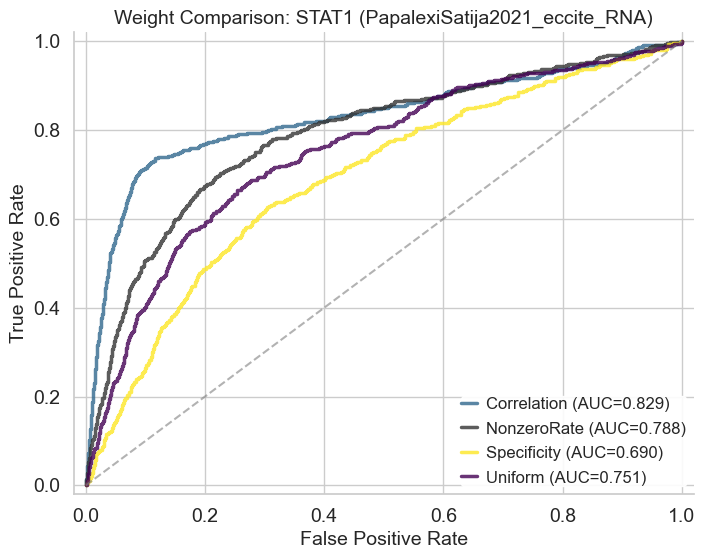

In [ ]:
def plot_roc_for_weights(targets_dict, dataset_meta):
    weight_colors = {
        "Uniform": "#44015480",  # Red
        "Correlation": "#31688e80",  # Blue
        "Non_Zero_Ratio": "#35b77980",  # Green
        "Specificity": "#fde72580",  # Purple
    }

    output_base_dir = "generated_scores"
    os.makedirs(output_base_dir, exist_ok=True)

    for dataset_name, tfs_to_plot in targets_dict.items():
        if dataset_name not in dataset_meta:
            print(f"Skipping {dataset_name}: Metadata not found.")
            continue

        print(f"\n{'=' * 80}")
        print(f"Processing Dataset: {dataset_name}")
        print(f"Target TFs: {tfs_to_plot}")
        print(f"{'=' * 80}")

        params = dataset_meta[dataset_name]
        is_activation = params["is_activation"]

        # 1. Load Ground Truth
        adata_path = f"scPerturbDatasets/{dataset_name}.h5ad"
        if not os.path.exists(adata_path):
            print(f"File not found: {adata_path}")
            continue

        adata = read_adata_file(adata_path)
        adata = preprocess_adata(adata)

        if "perturbation" in adata.obs.columns:
            adata.obs["condition_clean"] = adata.obs["perturbation"].apply(get_single_perturbation)
        else:
            adata.obs["condition_clean"] = adata.obs.index

        binary_matrix_full = pd.get_dummies(adata.obs["condition_clean"])
        available_tfs = [tf for tf in tfs_to_plot if tf in binary_matrix_full.columns]

        if not available_tfs:
            print("None of the requested TFs found in dataset.")
            del adata
            continue

        binary_matrix = binary_matrix_full[available_tfs].copy()
        binary_matrix.index = binary_matrix.index.astype(str)

        # 2. Load Scores (Specifically looking for z_aggregate variants)
        score_dir = f"generated_scores/{dataset_name}/"
        weight_dfs = {}

        if os.path.exists(score_dir):
            for file_name in os.listdir(score_dir):
                if file_name.endswith(".feather") and "z_aggregate_" in file_name:
                    try:
                        # Parse Filename: z_aggregate_WEIGHT_DatasetName.feather
                        parts = file_name.split("_")
                        weight_name = parts[2]
                        path = os.path.join(score_dir, file_name)
                        df = pd.read_feather(path)
                        if isinstance(df.index, pd.RangeIndex):
                            df = df.set_index(df.columns[0])
                        df.index = df.index.astype(str)
                        weight_dfs[weight_name] = df
                    except Exception as e:
                        print(f"Error loading {file_name}: {e}")

        if not weight_dfs:
            print("No z_aggregate weight files found.")
            continue

        # 3. Plotting Loop
        for tf in available_tfs:
            print(f"  -> Generating plot for {tf}...")

            fig, ax = plt.subplots(figsize=(8, 6))

            y_true_raw = binary_matrix[tf]
            plotted_any = False

            for weight_name in sorted(weight_dfs.keys()):
                score_df = weight_dfs[weight_name]
                common_cells = y_true_raw.index.intersection(score_df.index)
                if len(common_cells) == 0 or tf not in score_df.columns:
                    continue
                y_true = y_true_raw.loc[common_cells].values
                y_pred = score_df.loc[common_cells, tf].values
                if y_true.sum() < 1:
                    continue
                if not is_activation:
                    y_pred = -y_pred
                fpr, tpr, _ = roc_curve(y_true, y_pred)
                roc_auc = auc(fpr, tpr)
                color = weight_colors.get(weight_name, "#333333")
                ax.plot(
                    fpr,
                    tpr,
                    label=f"{weight_name} (AUC={roc_auc:.3f})",
                    color=color,
                    alpha=0.8,
                )
                plotted_any = True

            if plotted_any:
                ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", alpha=0.6)

                ax.set_xlim([-0.02, 1.02])
                ax.set_ylim([-0.02, 1.02])
                ax.set_xlabel("False Positive Rate")
                ax.set_ylabel("True Positive Rate")

                sns.despine(ax=ax)

                mode_str = "CRISPRa" if is_activation else "CRISPRi"
                ax.set_title(f"Weight Comparison: {tf} ({dataset_name})")

                ax.legend(
                    loc="lower right", frameon=True, framealpha=0.9, edgecolor="white"
                )

                # out_name = f"ROC_Weights_{dataset_name}_{tf}.svg"
                # out_path = os.path.join(output_base_dir, out_name)
                # plt.savefig(out_path, format="svg", dpi=300, bbox_inches="tight")
                plt.show()
                plt.close()
                # print(f"     [Saved] {out_path}")
            else:
                plt.close()
                print(f"     [Skipped] {tf}")

set_publication_style()

targets_to_plot = {
    "ReplogleWeissman2022_rpe1": ["ELL","SRF"],
    "ReplogleWeissman2022_K562_essential": ["GATA1","MAX"],
    "NormanWeissman2019_filtered": ["IRF1"],
    "PapalexiSatija2021_eccite_RNA": ["STAT1"]
}

try:
    plot_roc_for_weights(targets_to_plot, dataset_metadata)
except Exception as e:
    print("CRITICAL ERROR:", e)

#### Mann Whitney U Test

As we have already have activity scores of all datasets for all methods(z-aggregate, ulm, viper), we can directly read those files and perform Mann Whitney U Test to benchmark the methods.

In [7]:
adata_files_with_params = {
    # "FrangiehIzar2021_RNA": {
    #     "min_genes": 1000,
    #     "min_cells": 10,
    #     "is_activation": False,
    #     "common_perturbed_tfs": [
    #         "CCND1",
    #         "CDKN1A",
    #         "CDKN2A",
    #         "DNMT1",
    #         "E2F1",
    #         "FOS",
    #         "FOXM1",
    #         "IRF3",
    #         "JAK1",
    #         "JAK2",
    #         "KLF4",
    #         "MYC",
    #         "RB1",
    #         "RUVBL2",
    #         "SMAD3",
    #         "SMAD4",
    #         "STAT1",
    #         "STAT3",
    #         "TFAP2A",
    #         "TGFB1",
    #         "TIMP3",
    #         "TP53",
    #         "TSC22D3",
    #     ],
    # },
    # "ReplogleWeissman2022_rpe1": {
    #     "min_genes": 1000,
    #     "min_cells": 10,
    #     "is_activation": False,
    #     "common_perturbed_tfs": [
    #         "ACTL6A",
    #         "ATF4",
    #         "ATR",
    #         "BRCA1",
    #         "BTF3",
    #         "CCND1",
    #         "CCNH",
    #         "CCNK",
    #         "CDC6",
    #         "CDK12",
    #         "CDK7",
    #         "CDK9",
    #         "CHEK1",
    #         "CLOCK",
    #         "CTDP1",
    #         "DNMT1",
    #         "E2F6",
    #         "ELL",
    #         "ELOB",
    #         "ERCC2",
    #         "ERCC3",
    #         "ETV4",
    #         "FOXO1",
    #         "GABPA",
    #         "GABPB1",
    #         "GATA1",
    #         "GTF2F1",
    #         "GTF2F2",
    #         "GTF2H1",
    #         "GTF2H2",
    #         "GTF2H3",
    #         "GTF2H4",
    #         "HDAC3",
    #         "HDAC7",
    #         "HMGA1",
    #         "HSF1",
    #         "KAT5",
    #         "LIN52",
    #         "LIN54",
    #         "MAX",
    #         "MED1",
    #         "MNAT1",
    #         "MYB",
    #         "MYBL2",
    #         "MYC",
    #         "NANOG",
    #         "NELFA",
    #         "NELFB",
    #         "NELFCD",
    #         "NELFE",
    #         "NF1",
    #         "NFYB",
    #         "NFYC",
    #         "NPM1",
    #         "NRF1",
    #         "POLR2A",
    #         "POLR2B",
    #         "POLR2C",
    #         "POLR2D",
    #         "POLR2E",
    #         "POLR2F",
    #         "POLR2G",
    #         "POLR2H",
    #         "POLR2I",
    #         "POLR2K",
    #         "POLR2L",
    #         "RAD51",
    #         "RAD51D",
    #         "RBBP4",
    #         "RBMX",
    #         "RUVBL1",
    #         "RUVBL2",
    #         "SP1",
    #         "SRF",
    #         "SSRP1",
    #         "STAT5A",
    #         "STAT5B",
    #         "SUPT16H",
    #         "SUPT4H1",
    #         "SUPT5H",
    #         "TFDP1",
    #         "TGS1",
    #         "TNRC6A",
    #         "TRRAP",
    #         "USF2",
    #         "VHL",
    #         "YBX1",
    #         "YY1",
    #         "ZBTB17",
    #     ],
    # },
    # "ReplogleWeissman2022_K562_essential": {
    #     "min_genes": 1000,
    #     "min_cells": 10,
    #     "is_activation": False,
    #     "common_perturbed_tfs": [
    #         "ACTL6A",
    #         "ASF1B",
    #         "ATF4",
    #         "ATR",
    #         "BRCA1",
    #         "CCND1",
    #         "CCNH",
    #         "CCNK",
    #         "CDC6",
    #         "CDK7",
    #         "CDK9",
    #         "CHEK1",
    #         "CTDP1",
    #         "DNMT1",
    #         "E2F6",
    #         "ELL",
    #         "ERCC2",
    #         "ERCC3",
    #         "GABPA",
    #         "GATA1",
    #         "GTF2F1",
    #         "GTF2F2",
    #         "GTF2H1",
    #         "GTF2H2",
    #         "GTF2H3",
    #         "GTF2H4",
    #         "HDAC3",
    #         "HDAC7",
    #         "HSF1",
    #         "KAT5",
    #         "LIN52",
    #         "LIN54",
    #         "MAX",
    #         "MCM5",
    #         "MED1",
    #         "MNAT1",
    #         "MYBL2",
    #         "MYC",
    #         "NANOG",
    #         "NELFA",
    #         "NELFB",
    #         "NELFCD",
    #         "NELFE",
    #         "NFYB",
    #         "NFYC",
    #         "NPM1",
    #         "NRF1",
    #         "POLR2A",
    #         "POLR2B",
    #         "POLR2C",
    #         "POLR2D",
    #         "POLR2E",
    #         "POLR2F",
    #         "POLR2G",
    #         "POLR2H",
    #         "POLR2I",
    #         "POLR2K",
    #         "POLR2L",
    #         "RAD51",
    #         "RAD51D",
    #         "RBBP4",
    #         "RBMX",
    #         "RUVBL1",
    #         "RUVBL2",
    #         "SSRP1",
    #         "STAT5A",
    #         "SUPT16H",
    #         "SUPT4H1",
    #         "SUPT5H",
    #         "TFDP1",
    #         "TGS1",
    #         "TRRAP",
    #         "USF2",
    #         "VHL",
    #         "YBX1",
    #         "YY1",
    #         "ZBTB17",
    #     ],
    # },
    "TianKampmann2021_CRISPRa": {
        "min_genes": 1000,
        "min_cells": 10,
        "is_activation": True,
        "common_perturbed_tfs": ["ATM", "BCL2", "HDAC9", "MEF2C", "POU4F1", "PPARGC1A", "SPI1", "TP53"],
    },
    "TianKampmann2021_CRISPRi": {
        "min_genes": 1000,
        "min_cells": 10,
        "is_activation": False,
        "common_perturbed_tfs": ["APEX1", "CREBBP", "GTF2H3", "MTA1", "PARP1", "POU4F1"],
    },
    # "NormanWeissman2019_filtered": {
    #     "min_genes": 1000,
    #     "min_cells": 10,
    #     "is_activation": True,
    #     "common_perturbed_tfs": [
    #         "AHR",
    #         "CDKN1A",
    #         "CEBPA",
    #         "CEBPB",
    #         "EGR1",
    #         "ETS2",
    #         "FOXA1",
    #         "FOXL2",
    #         "FOXO4",
    #         "HNF4A",
    #         "IRF1",
    #         "JUN",
    #         "MAML2",
    #         "MAPK1",
    #         "SNAI1",
    #         "SPI1",
    #         "TP73",
    #     ],
    # },
    "PapalexiSatija2021_eccite_RNA": {
        "min_genes": 1000,
        "min_cells": 10,
        "is_activation": False,
        "common_perturbed_tfs": [
            "ATF2",
            "IRF1",
            "JAK2",
            "MYC",
            "NFKBIA",
            "SMAD4",
            "SPI1",
            "STAT1",
            "STAT3",
            "STAT5A",
        ],
    },
    # "GasperiniShendure2019_lowMOI": {
    #     "min_genes": 1000,
    #     "min_cells": 10,
    #     "is_activation": False,
    #     "common_perturbed_tfs": [
    #         "APEX1",
    #         "BTF3",
    #         "CEBPB",
    #         "GATA2",
    #         "H3F3B",
    #         "LMO2",
    #         "MAX",
    #         "MYC",
    #         "NPM1",
    #         "POLR2K",
    #         "PTTG1",
    #         "RBBP4",
    #         "RBMX",
    #         "TAF12",
    #     ],
    # },
}


In [22]:
from scipy.stats import mannwhitneyu
from scipy import stats

def mann_whitney_u_test_perturbed_v_control(
    scores_series, marked_indices, control_indices, is_activation=False
):
    valid_marked = marked_indices[marked_indices.isin(scores_series.index)]
    valid_control = control_indices[control_indices.isin(scores_series.index)]

    if len(valid_marked) < 2 or len(valid_control) < 2:
        return 0.0, 1.0, 0.0

    vals_marked = scores_series[valid_marked]
    vals_control = scores_series[valid_control]

    alt = "greater" if is_activation else "less"

    try:
        u_stat, p_val = mannwhitneyu(
            vals_marked,
            vals_control,
            axis=0,
            nan_policy="omit",
            alternative=alt,
        )
    except Exception:
        return 0.0, 1.0, 0.0

    mean_diff = vals_marked.mean() - vals_control.mean()
    return u_stat, p_val, mean_diff



base_results_dir = "generated_scores"
output_mw_dir = "mann_whitney"
mann_whitney_u_test_df = pd.DataFrame()

for dataset_name, params in adata_files_with_params.items():
    print(f"\n{'=' * 40}\nProcessing {dataset_name}\n{'=' * 40}")

    # Paths
    dataset_path = os.path.join(dataset_directory, dataset_name + ".h5ad")
    output_dir = os.path.join(base_results_dir, dataset_name)

    if not os.path.exists(output_dir):
        print(f"Skipping: Results directory not found at {output_dir}")
        continue

    # 2. Load & Preprocess
    try:
        adata = sc.read_h5ad(dataset_path)
    except Exception as e:
        print(f"Error reading dataset {dataset_path}: {e}")
        continue

    # Safe parameter retrieval
    adata = preprocess_adata(adata, min_genes=params.get("min_genes", 1000), min_cells=params.get("min_cells", 10))

    # 3. Clean Perturbation Labels
    if "perturbation" in adata.obs.columns:
        adata.obs["condition_clean"] = adata.obs["perturbation"].apply(get_single_perturbation)
    else:
        print("   [WARN] 'perturbation' column missing. Skipping...")
        continue

    # 4. Identify Control Cells (Non-Targeting)
    control_cells = adata.obs[adata.obs["condition_clean"] == "control"].index
    print(f"   Control cells (N={len(control_cells)}) identified.")

    # 5. Load Method Scores
    method_scores = {}
    avail_files = [f for f in os.listdir(output_dir) if f.endswith(".feather")]

    print(f"   Loading {len(avail_files)} score files...")
    for f in avail_files:
        method_key = f.replace(f"_{dataset_name}.feather", "")
        try:
            method_scores_df = pd.read_feather(os.path.join(output_dir, f))
            if isinstance(method_scores_df.index, pd.RangeIndex):
                first_col = method_scores_df.columns[0]
                method_scores_df = method_scores_df.set_index(first_col)

            # Reindex
            method_scores_df = method_scores_df.reindex(columns=params["common_perturbed_tfs"], fill_value=0)
            method_scores[method_key] = method_scores_df

        except Exception as e:
            print(f"Error loading {f}: {e}")

    # 6. Benchmarking Loop
    results_vs_control = []
    results_vs_rest = []

    target_tfs = params["common_perturbed_tfs"]
    is_act = params["is_activation"]

    for tf in tqdm(target_tfs, desc="Benchmarking TFs"):
        # Perturbed Cells
        marked_cells = adata.obs[adata.obs["condition_clean"] == tf].index
        if len(marked_cells) < 3:
            continue

        # --- Methods ---
        for m_name, df_scores in method_scores.items():
            if tf not in df_scores.columns:
                continue

            # Get scores strictly for cells in this method file & adata
            common_cells = df_scores.index.intersection(adata.obs_names)
            series_scores = df_scores.loc[common_cells, tf]

            # Marked vs Control
            u_c, p_c, md_c = mann_whitney_u_test_perturbed_v_control(
                series_scores, marked_cells, control_cells, is_act
            )
            results_vs_control.append(
                {
                    "TF": tf,
                    "Method": m_name,
                    "N_Pert": len(marked_cells.intersection(common_cells)),
                    "U_Stat": u_c,
                    "P_Value": p_c,
                    "Mean_Diff": md_c,
                    "Score": -np.log(p_c + 1e-300),
                }
            )

    if results_vs_control:
        os.makedirs(output_mw_dir, exist_ok=True)
        mann_whitney_u_test_df = pd.DataFrame(results_vs_control)
        
        # If Mean_Diff is 0.0 and P_Value is 1.0, then replace with 0.5
        mann_whitney_u_test_df.loc[
            (mann_whitney_u_test_df["Mean_Diff"] == 0.0) & (mann_whitney_u_test_df["P_Value"] == 1.0),
            "P_Value"
        ] = 0.5
        
        out_file_ctrl = os.path.join(
            output_mw_dir, f"MannWhitney_U_Test_{dataset_name}.tsv"
        )
        mann_whitney_u_test_df.to_csv(out_file_ctrl, sep="\t", index=False)
        print(f"   Saved Vs Control: {out_file_ctrl}")


Processing TianKampmann2021_CRISPRa


2026-01-28 12:07:12 | [INFO] Starting Preprocessing...
2026-01-28 12:07:13 | [INFO]    Filtered cells (min_genes=1000): Removed 941 cells.
2026-01-28 12:07:13 | [INFO]    Filtered genes (min_cells=10): Removed 13170 genes.
2026-01-28 12:07:14 | [INFO]    Mitochondrial filter (<20.0%): Removed 1097 cells.
2026-01-28 12:07:15 | [INFO] Preprocessing complete. Final shape: 19155 cells x 20368 genes


   Control cells (N=400) identified.
   Loading 12 score files...


Benchmarking TFs:   0%|          | 0/8 [00:00<?, ?it/s]

   Saved Vs Control: mann_whitney/MannWhitney_U_Test_TianKampmann2021_CRISPRa.tsv

Processing TianKampmann2021_CRISPRi


...

   Saved Vs Control: mann_whitney/MannWhitney_U_Test_TianKampmann2021_CRISPRi.tsv

Processing PapalexiSatija2021_eccite_RNA


2026-01-28 12:07:28 | [INFO] Starting Preprocessing...
2026-01-28 12:07:29 | [INFO]    Filtered cells (min_genes=1000): Removed 0 cells.
2026-01-28 12:07:29 | [INFO]    Filtered genes (min_cells=10): Removed 915 genes.
2026-01-28 12:07:29 | [INFO]    Mitochondrial filter (<20.0%): Removed 0 cells.
2026-01-28 12:07:30 | [INFO] Preprocessing complete. Final shape: 20729 cells x 17734 genes


   Control cells (N=2386) identified.
   Loading 12 score files...


Benchmarking TFs:   0%|          | 0/10 [00:00<?, ?it/s]

   Saved Vs Control: mann_whitney/MannWhitney_U_Test_PapalexiSatija2021_eccite_RNA.tsv


#### Merging p-values using stouffer's method

In [23]:
# Here we combine scores from multiple dataset into single dataframe, following stouffer p-value combine
files = [
    f
    for f in os.listdir(output_mw_dir)
    if f.endswith(".tsv")
    and f.startswith("MannWhitney_U_Test_")
]

data_frames = []
# Load all datasets
for filename in files:
    file_path = os.path.join(output_mw_dir, filename)
    try:
        df = pd.read_csv(file_path, sep='\t')
        data_frames.append(df)
    except Exception as e:
        print(f"Could not read {filename}: {e}")

if not data_frames:
    raise ValueError("No files were loaded. Check your directory path.")
# Combine into one large DataFrame
combined_df = pd.concat(data_frames, ignore_index=True)


def run_stouffer(p_values):
    p_values = p_values.dropna().values

    if len(p_values) == 0:
        return np.nan
    if len(p_values) == 1:
        return p_values[0]

    p_values = np.clip(p_values, 1e-300, 1 - 1e-16)
    _, combined_p = stats.combine_pvalues(p_values, method="stouffer")
    return combined_p


stouffer_results = (
    combined_df.groupby(["TF", "Method"])["P_Value"]
    .agg(run_stouffer)
    .reset_index()
)

stouffer_results.rename(columns={'P_Value': 'Stouffer_P_Value'}, inplace=True)
pivot_results = stouffer_results.pivot(index='TF', columns='Method', values='Stouffer_P_Value')
stouffer_results.to_csv(f"{output_mw_dir}/stouffer_combined_pvalues.tsv", sep="\t", index=False)
stouffer_results.head()

,TF,Method,Stouffer_P_Value
0,APEX1,ulm_Correlation,0.057963
1,APEX1,ulm_NonzeroRate,0.082975
2,APEX1,ulm_Specificity,0.302839
3,APEX1,ulm_Uniform,0.084864
4,APEX1,viper_Correlation,0.196013


#### Plot Venn Diagram of three methods: z-aggregate, ulm, viper

Processing...
Saved to results/venn_3_methods.svg


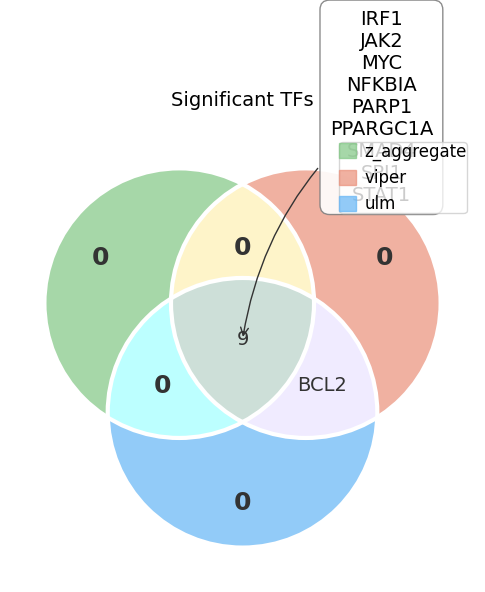

In [ ]:
from matplotlib import pyplot as plt
from statsmodels.stats.multitest import multipletests
import itertools
from matplotlib_venn import venn3, venn3_circles
import matplotlib.patches as mpatches

P_VALUE_THRESHOLD = 0.1

# Load Data
file_path = f"{output_mw_dir}/stouffer_combined_pvalues.tsv"
stouffer_pvalues = pd.read_csv(file_path, sep="\t")


def get_sig_tfs(df, method_name):
    if df.empty:
        return set()

    subset = df[df["Method"].str.contains(method_name, case=False, regex=False)]
    if subset.empty:
        print(f"Warning: No data found for method containing '{method_name}'")
        return set()

    _, pval_fdr, _, _ = multipletests(
        subset["Stouffer_P_Value"], method="fdr_bh", is_sorted=False
    )
    subset["FDR_P_Value"] = pval_fdr
    subset = subset[subset["FDR_P_Value"] < P_VALUE_THRESHOLD]
    return set(subset["TF"])


def get_disjoint_tf_sets(set_a, set_b, set_c, labels):
    label_a, label_b, label_c = labels
    only_a = set_a - set_b - set_c
    only_b = set_b - set_a - set_c
    only_c = set_c - set_a - set_b
    a_b_excl_c = (set_a & set_b) - set_c
    a_c_excl_b = (set_a & set_c) - set_b
    b_c_excl_a = (set_b & set_c) - set_a
    all_three = set_a & set_b & set_c
    data_dict = {
        label_a: only_a,
        label_b: only_b,
        label_c: only_c,
        f"{label_a}_{label_b}": a_b_excl_c,
        f"{label_a}_{label_c}": a_c_excl_b,
        f"{label_b}_{label_c}": b_c_excl_a,
        f"{label_a}_{label_b}_{label_c}": all_three,
    }
    return data_dict


def create_styled_venn(data_dict, labels, output_filename, title=None):
    def get_subset_tfs(*names):
        if len(names) == 1:
            return data_dict.get(names[0], set())
        for p in itertools.permutations(names):
            key = "_".join(p)
            if key in data_dict:
                return data_dict[key]
        return set()

    # 1. Configuration
    A, B, C = labels[0], labels[1], labels[2]

    # Retrieve the Sets
    set_100 = get_subset_tfs(A)
    set_010 = get_subset_tfs(B)
    set_110 = get_subset_tfs(A, B)
    set_001 = get_subset_tfs(C)
    set_101 = get_subset_tfs(A, C)
    set_011 = get_subset_tfs(B, C)
    set_111 = get_subset_tfs(A, B, C)

    # Map IDs to the actual Set of TFs for easy lookup later
    id_to_set = {
        "100": set_100,
        "010": set_010,
        "110": set_110,
        "001": set_001,
        "101": set_101,
        "011": set_011,
        "111": set_111,
    }

    # LAYOUT DATA: Used *only* to draw the shapes.
    layout_subsets = (
        20,  # Region A only
        20,  # Region B only
        3,  # Intersection A-B
        20,  # Region C only
        3,  # Intersection A-C
        3,  # Intersection B-C
        14,  # Intersection A-B-C
    )

    colors = ["#81C784", "#EA907A", "#64B5F6"]
    plt.figure(figsize=(6, 6), facecolor="white")

    # 2. Draw the Colored Regions
    v = venn3(
        subsets=layout_subsets,
        set_labels=(None, None, None),
        set_colors=colors,
        alpha=0.7,
    )

    # 3. Draw the Borders
    venn3_circles(subsets=layout_subsets, linestyle="-", linewidth=3, color="white")

    # 4. Custom Logic: Labels and Annotations
    ids = ["100", "010", "110", "001", "101", "011", "111"]

    # Coordinates to push annotation boxes away from center (x_offset, y_offset)
    annotation_offsets = {
        "100": (-80, 40),  # Top Left
        "010": (80, 40),  # Top Right
        "001": (0, -80),  # Bottom
        "110": (0, 70),  # Top Center
        "101": (-70, -60),  # Bottom Left
        "011": (70, -60),  # Bottom Right
        "111": (100, 100),  # Far corner
    }

    for i, id_str in enumerate(ids):
        lbl = v.get_label_by_id(id_str)
        if not lbl:
            continue

        current_set = id_to_set[id_str]
        count = len(current_set)

        lbl.set_family("sans-serif")
        lbl.set_color("#333333")

        if 6 > count > 0:
            display_text = "\n".join(sorted(list(current_set)))
            lbl.set_text(display_text)
            lbl.set_fontsize(14)
            # lbl.set_fontweight('bold')

        elif 6 <= count <= 14:
            # 1. Number inside
            lbl.set_text(str(count))
            lbl.set_fontsize(14)

            # 2. Annotation Box outside
            x_pos, y_pos = lbl.get_position()
            offset = annotation_offsets.get(id_str, (50, 50))

            tf_list_str = "\n".join(sorted(list(current_set)))

            plt.annotate(
                tf_list_str,
                xy=(x_pos, y_pos), 
                xytext=offset,
                textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9),
                arrowprops=dict(
                    arrowstyle="->", connectionstyle="arc3,rad=0.2", color="#333333"
                ),
                fontsize=14,
                ha="center",
                family="sans-serif",
            )

        else:
            lbl.set_text(str(count))
            lbl.set_fontsize(18)
            lbl.set_fontweight("bold")

    # 5. Create the Custom Legend
    legend_handles = []
    for color, label in zip(colors, labels):
        patch = mpatches.Patch(color=color, label=label, alpha=0.7)
        legend_handles.append(patch)

    plt.tight_layout()
    if title:
        plt.title(title, fontsize=14, family="sans-serif", pad=20)

    plt.legend(
        handles=legend_handles,
        loc="upper right",
        bbox_to_anchor=(1, 1),
        frameon=True,
        fontsize=12,
    )
    plt.tight_layout()

    # 6. Save output
    plt.savefig(output_filename, format="svg", bbox_inches="tight", dpi=800)
    print(f"Saved to {output_filename}")
    plt.show()
    plt.close()


# Standard labels for the Venn Diagram
labels = ["z_aggregate", "viper", "ulm"]

# 1. Analysis
print("Processing...")
u_method1 = "z_aggregate_Uniform"
u_method2 = "viper_Uniform"
u_method3 = "ulm_Uniform"

set_u1 = get_sig_tfs(stouffer_pvalues, u_method1)
set_u2 = get_sig_tfs(stouffer_pvalues, u_method2)
set_u3 = get_sig_tfs(stouffer_pvalues, u_method3)

data_u = get_disjoint_tf_sets(set_u1, set_u2, set_u3, labels)
create_styled_venn(
    data_u,
    labels,
    "results/venn_3_methods.svg",
    title="Significant TFs",
)

#### Plot venn diagram of four different target weight strategies

Plot saved to: results/four_weights_venn_diagram.svg


<Figure size 1200x1200 with 0 Axes>

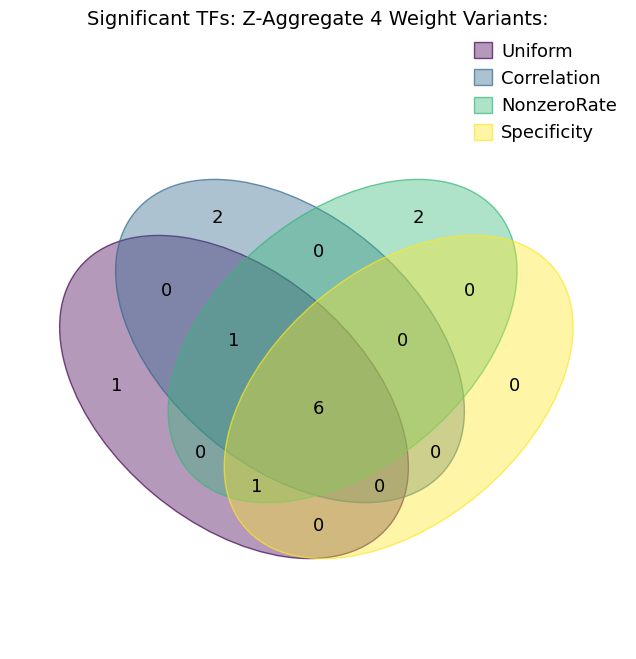


--- Detailed Intersections for 4 Variants ---
Region 0010 [NonzeroRate]: 2 TFs
 -> BCL2, CREBBP
Region 0100 [Correlation]: 2 TFs
 -> APEX1, STAT3
Region 1000 [Uniform]: 1 TFs
 -> NFKBIA
Region 1011 [Uniform & NonzeroRate & Specificity]: 1 TFs
 -> SPI1
Region 1110 [Uniform & Correlation & NonzeroRate]: 1 TFs
 -> PARP1
Region 1111 [Uniform & Correlation & NonzeroRate & Specificity]: 6 TFs
 -> IRF1, JAK2, MYC, PPARGC1A, SMAD4, STAT1


In [20]:
from venn import venn

P_VALUE_THRESHOLD = 0.1

# Load Data
file_path = f"{output_mw_dir}/stouffer_combined_pvalues.tsv"
stouffer_pvalues = pd.read_csv(file_path, sep="\t")


za_method1 = "z_aggregate_Uniform"
za_method2 = "z_aggregate_Correlation"
za_method3 = "z_aggregate_NonzeroRate"
za_method4 = "z_aggregate_Specificity"


set_za1 = get_sig_tfs(stouffer_pvalues, za_method1)
set_za2 = get_sig_tfs(stouffer_pvalues, za_method2)
set_za3 = get_sig_tfs(stouffer_pvalues, za_method3)
set_za4 = get_sig_tfs(stouffer_pvalues, za_method4)


sets_data = {
    "Uniform": set_za1,
    "Correlation": set_za2,
    "NonzeroRate": set_za3,
    "Specificity": set_za4,
}

# --- 1. Pre-Calculate Intersections for Label Mapping ---
intersection_map = {}

set_names = [
    "Uniform",
    "Correlation",
    "NonzeroRate",
    "Specificity",
]
set_objects = [set_za1, set_za2, set_za3, set_za4]

# Iterate 1 to 15 (binary 0001 to 1111)
for i in range(1, 16):
    binary_sig = format(i, "04b")

    included_sets = [
        set_objects[idx] for idx, char in enumerate(binary_sig) if char == "1"
    ]
    excluded_sets = [
        set_objects[idx] for idx, char in enumerate(binary_sig) if char == "0"
    ]

    if not included_sets:
        continue

    # Calculate specific intersection
    region_tfs = set.intersection(*included_sets)
    if excluded_sets:
        region_tfs = region_tfs - set.union(*excluded_sets)

    count = len(region_tfs)

    if count > 0:
        if count not in intersection_map:
            intersection_map[count] = []
        intersection_map[count].append(region_tfs)

# --- 2. Plotting ---
plt.figure(figsize=(12, 12))
venn(sets_data)
plt.title(
    "Significant TFs: Z-Aggregate 4 Weight Variants:", fontsize=14
)

# --- 3. Modify Labels (Replace numbers with Names) ---
ax = plt.gca()

for text_obj in ax.texts:
    txt = text_obj.get_text()

    if txt.isdigit():
        val = int(txt)

        if 0 < val < 4:
            if val in intersection_map:
                possible_tf_sets = intersection_map[val]

                if len(possible_tf_sets) == 1:
                    tfs = sorted(list(possible_tf_sets[0]))
                    new_label = "\n".join(tfs)
                    text_obj.set_text(new_label)
                    text_obj.set_fontsize(12)
                else:
                    print(
                        f"Warning: Multiple regions have exactly {val} TFs. "
                        f"Cannot safely map names to plot for count {val}."
                    )

# --- 4. Save as SVG ---
output_file = "results/four_weights_venn_diagram.svg"
plt.savefig(output_file, format="svg", bbox_inches="tight")
print(f"Plot saved to: {output_file}")
plt.show()

# --- 5. Print Detailed Text Intersections (Console Output) ---
print("\n--- Detailed Intersections for 4 Variants ---")

for i in range(1, 16):
    binary_sig = format(i, "04b")

    included_names = []
    included_sets = []
    excluded_sets = []

    for idx, char in enumerate(binary_sig):
        if char == "1":
            included_sets.append(set_objects[idx])
            included_names.append(set_names[idx])
        else:
            excluded_sets.append(set_objects[idx])

    if not included_sets:
        continue

    region_tfs = set.intersection(*included_sets)
    if excluded_sets:
        region_tfs = region_tfs - set.union(*excluded_sets)

    count = len(region_tfs)
    tf_list = sorted(list(region_tfs))

    if count > 0:
        readable_label = " & ".join(included_names)
        print(f"Region {binary_sig} [{readable_label}]: {count} TFs")
        if count <= 20:
            print(f" -> {', '.join(tf_list)}")
        else:
            print(" -> (List too long to display)")